# Initialization

In [1]:
%load_ext autoreload
%autoreload 2

## Imports

In [2]:
import warnings
# warnings.filterwarnings(action='once')
warnings.filterwarnings('ignore')

In [3]:
import os
import itertools
from collections import OrderedDict
import math
from pathlib import Path

import pandas as pd 
import wandb
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
from drvi_notebooks.utils.data.data_configs import get_data_info
from drvi_notebooks.utils.run_info import get_run_info_for_dataset
from drvi_notebooks.utils.method_info import pretify_method_name
from drvi_notebooks.utils.misc import compare_objs_recursive

## Config

In [5]:
cwd = os.getcwd()
cwd

'/ictstr01/home/icb/amirali.moinfar/projects/drvi_reproducibility_public/drvi_notebooks/analysis'

In [6]:
proj_dir = Path(cwd).parent.parent
proj_dir

PosixPath('/ictstr01/home/icb/amirali.moinfar/projects/drvi_reproducibility_public')

In [7]:
(proj_dir / 'plots' / 'metrics_over_time').mkdir(parents=True, exist_ok=True)

# Run Data

## Retrieve

## Find relevant runs

## Make history

In [8]:
datasets = OrderedDict([
    ('pancreas_scvelo', dict(
        name='Developmental\npancreas',
    )),
    ('hlca', dict(
        name='Human lung\ncell atlas',
    )),
    ('norman_hvg', dict(
        # name='Norman\nPerturb-seq',
        name='CRISPR screen\n',
    )),
    ('retina_organoid_hvg', dict(
        name='Retina organoid\n',
    )),
    ('immune_hvg', dict(
        name='Immune\n',
    )),
    ('pbmc_covid_hvg', dict(
        name='PBMC\n',
    )),
    ('zebrafish_hvg', dict(
        # name='Zebrafish\n',
        name='Daniocell\n',
    )),
])
datasets_to_inspect = [
    'pancreas_scvelo', #'zebrafish_hvg',
    'norman_hvg',
    'retina_organoid_hvg', 'immune_hvg', 'hlca',  'pbmc_covid_hvg',
]
runs_to_inspect = ['DRVI', 'DRVI-NC', 'DRVI-IK', 'DRVI-CVAE']

In [9]:
history_dict = {}
run_version = '4.3'

for ds_name in datasets_to_inspect:
    history_dict[ds_name] = {}
    run_dirs = {
        **get_run_info_for_dataset(ds_name).run_dirs, 
        **get_run_info_for_dataset(ds_name + '_drs').run_dirs
    }
    data_info = get_data_info(ds_name, run_version)

    possible_wandb_addresses = [
        data_info['wandb_address'],
        "unconstrained_DRVI_runs_drvi_4.7",
    ]
    for wandb_address in possible_wandb_addresses:
        api = wandb.Api()
        runs = api.runs(f"moinfar_proj/{wandb_address}")
    
        for model_name in run_dirs.keys():
            if model_name in runs_to_inspect:
                run_dir = run_dirs[model_name]
                run_id = str(run_dirs[model_name]).split("/")[-1]
                run_obj = [run for run in runs if run.name == run_id]
                if len(run_obj) >= 1:
                    run_obj = run_obj[0]
                else:
                    continue
        
                val_history = run_obj.history(samples=1000000, keys=[
                    "epoch", 
                    "validation_loss", "reconstruction_loss_validation", "elbo_validation", "mse_validation", "kl_local_validation",
                ]).drop(columns='_step')
                train_history = run_obj.history(samples=1000000, keys=[
                    "epoch", 
                    "train_loss_epoch", "reconstruction_loss_train", "elbo_train", "mse_train", "kl_local_train",
                ]).drop(columns='_step')
                
                history_df = pd.merge(val_history, train_history, on='epoch')
                history_df['method'] = pretify_method_name(model_name)
                history_dict[ds_name][model_name] = history_df

print({ds_name: list(v.keys()) for ds_name, v in history_dict.items()})

{'pancreas_scvelo': ['DRVI', 'DRVI-IK', 'DRVI-CVAE', 'DRVI-NC'], 'norman_hvg': ['DRVI', 'DRVI-IK', 'DRVI-CVAE', 'DRVI-NC'], 'retina_organoid_hvg': ['DRVI', 'DRVI-IK', 'DRVI-CVAE', 'DRVI-NC'], 'immune_hvg': ['DRVI', 'DRVI-IK', 'DRVI-CVAE', 'DRVI-NC'], 'hlca': ['DRVI', 'DRVI-IK', 'DRVI-CVAE', 'DRVI-NC'], 'pbmc_covid_hvg': ['DRVI', 'DRVI-IK', 'DRVI-CVAE', 'DRVI-NC']}


# Plotting

In [10]:
metric_titles = {
    "validation_loss": "Validation loss", 
    "reconstruction_loss_validation": "Validation reconstruction loss", 
    "elbo_validation": "Validation ELBO", 
    "mse_validation": "Validation MSE loss", 
    "kl_local_validation": "Validation KL loss", 
    "train_loss_epoch": "Train loss", 
    "reconstruction_loss_train": "Train reconstruction loss", 
    "elbo_train": "Train ELBO", 
    "mse_train": "Train MSE loss", 
    "kl_local_train": "Train KL loss", 
}

In [11]:
def plot_metric_over_epoch(history_dict, metric_name):
    # Combine all dataframes into a single dataframe
    combined_df = pd.concat(history_dict.values(), ignore_index=True)
    combined_df['epoch'] += 1
    
    # Ensure that the metric exists in the DataFrames
    if metric_name not in combined_df.columns:
        raise ValueError(f"The metric '{metric_name}' is not found in the dataframes.")
    
    # Set up the seaborn style
    sns.set(style="whitegrid")
    
    # Plot the metric over epoch, colored by method
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=combined_df,
        x='epoch', 
        y=metric_name, 
        hue='method', 
        # marker='.'
    )

    y_max = combined_df.query('epoch >= 10')[metric_name].max()
    y_min = combined_df[metric_name].min()
    y_min, y_max = y_min - (y_max - y_min) / 20, y_max + (y_max - y_min) / 20
    plt.ylim(y_min, y_max)
    
    plt.title(f'{metric_name} Over Epochs by Method')
    plt.xlabel('Epoch')
    plt.ylabel(metric_name)
    plt.legend(title='Method')
    plt.tight_layout()
    plt.show()

In [12]:
def plot_metric_across_datasets(super_history_dict, metric_name):
    num_datasets = len(super_history_dict)
    # Calculate number of rows and columns for the grid of subplots
    num_cols = min(10, num_datasets)  # Set a maximum of 3 plots per row
    num_rows = math.ceil(num_datasets / num_cols)

    # Set up the figure size dynamically based on number of datasets
    plt.figure(figsize=(3 * num_cols, 3 * num_rows))

    # Iterate over each dataset in super_history_dict
    for i, (dataset_name, history_dict) in enumerate(super_history_dict.items(), 1):
        combined_df = pd.concat(history_dict, ignore_index=True)
        combined_df['epoch'] += 1  # Assuming you want to increment the epoch by 1

        if metric_name not in combined_df.columns:
            raise ValueError(f"The metric '{metric_name}' is not found in the dataframes for {dataset_name}.")
        
        # Add subplot for the current dataset
        plt.subplot(num_rows, num_cols, i)
        
        # Set up the seaborn style
        sns.set(style="whitegrid")
        
        # Plot the metric over epoch for this dataset
        sns.lineplot(
            data=combined_df,
            x='epoch', 
            y=metric_name, 
            hue='method',
            # marker='o'
        )

        # Adjust y-limits if needed (same logic as before)
        y_max = combined_df.query('epoch >= 5')[metric_name].max()
        y_min = combined_df[metric_name].min()
        y_min, y_max = y_min - (y_max - y_min) / 20, y_max + (y_max - y_min) / 20
        plt.ylim(y_min, y_max)

        # Add titles and labels
        plt.title(datasets[dataset_name]['name'])
        plt.xlabel('Epoch')

        if i == 1:
            plt.ylabel(metric_titles[metric_name])
        else:
            plt.ylabel(None)
        
        if i == len(super_history_dict):
            
            # Add legend for each subplot
            ax = plt.gca()
            plt.legend(title='Method', bbox_to_anchor=(2., 1.), bbox_transform=ax.transAxes, frameon=False)
        else:
            ax = plt.gca()
            ax.get_legend().remove()

validation_loss


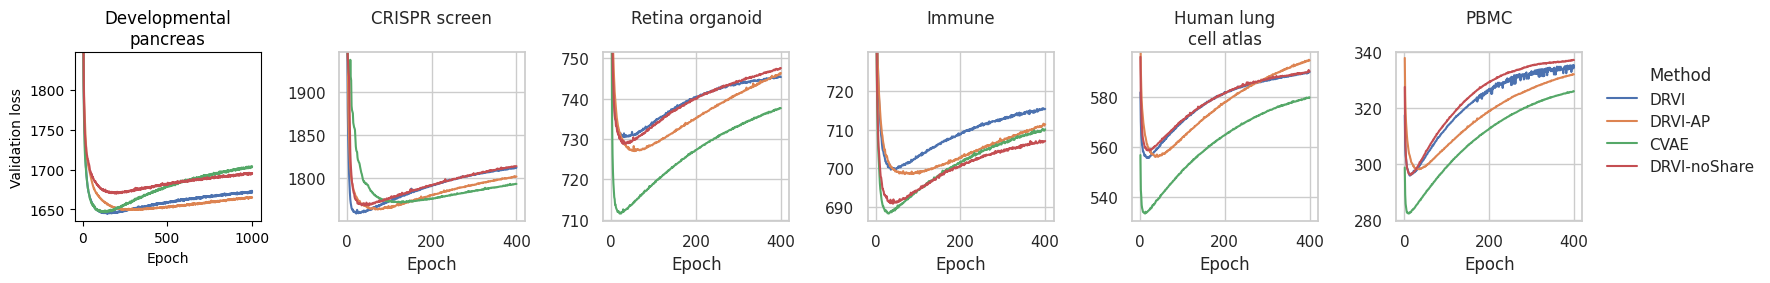

reconstruction_loss_validation


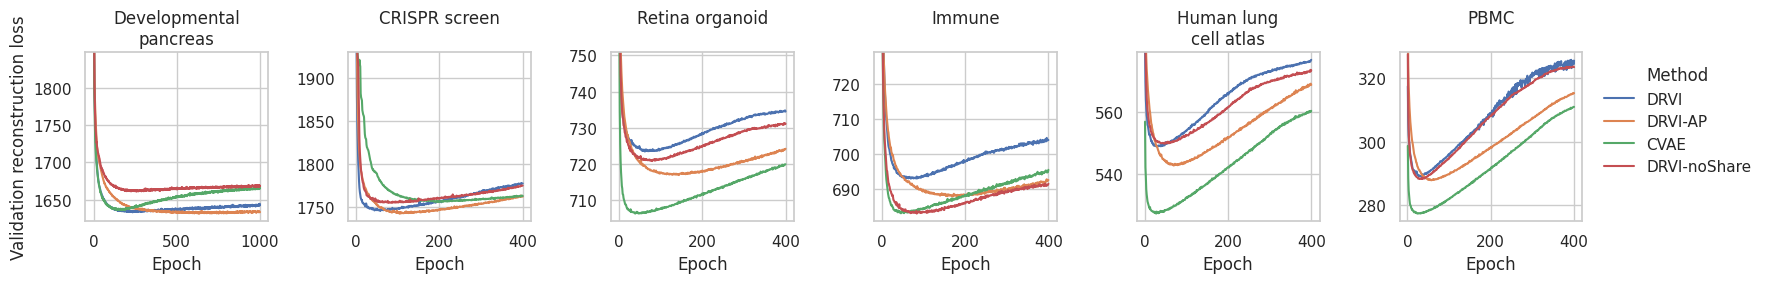

elbo_validation


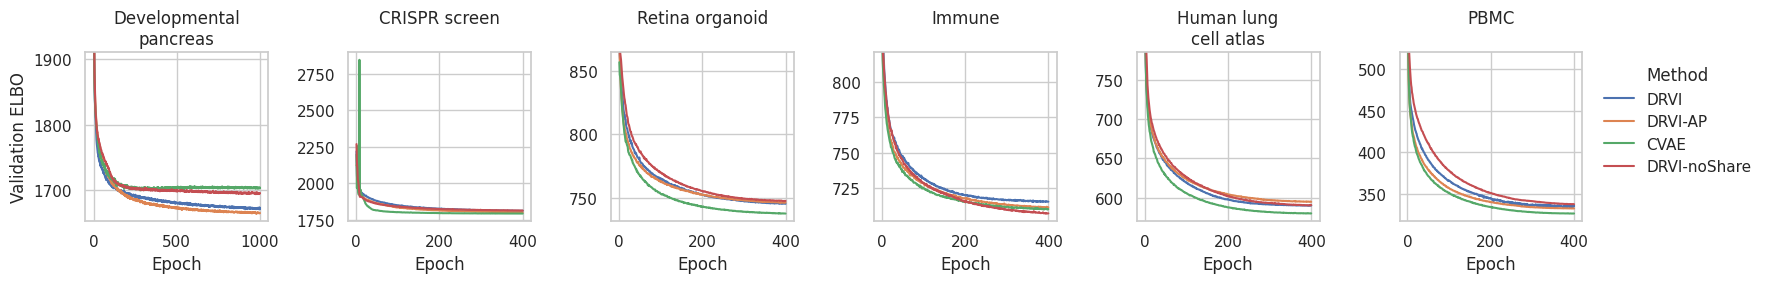

mse_validation


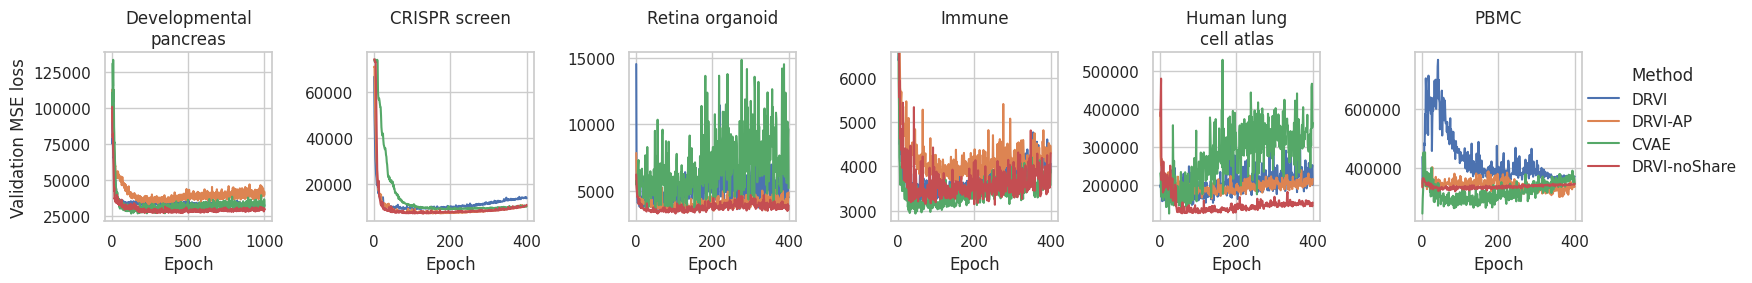

kl_local_validation


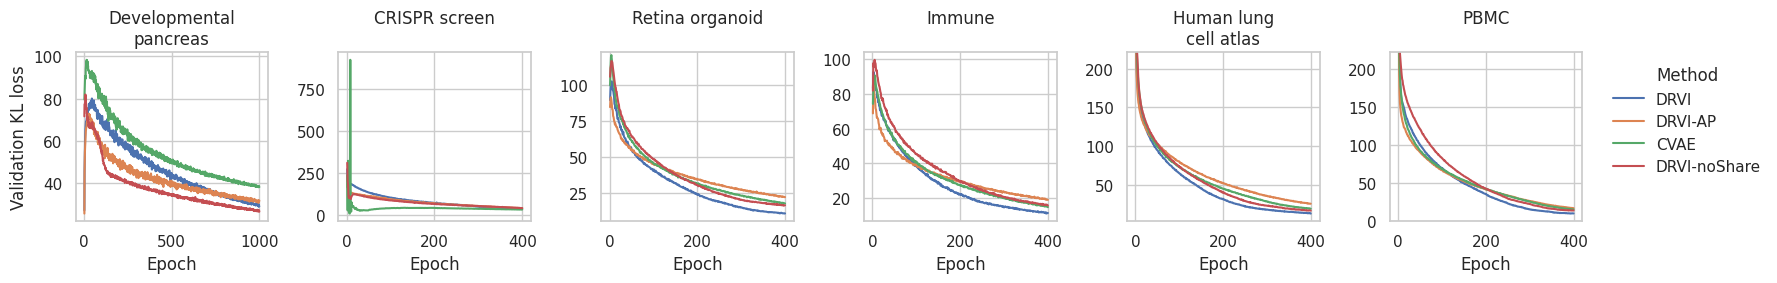

train_loss_epoch


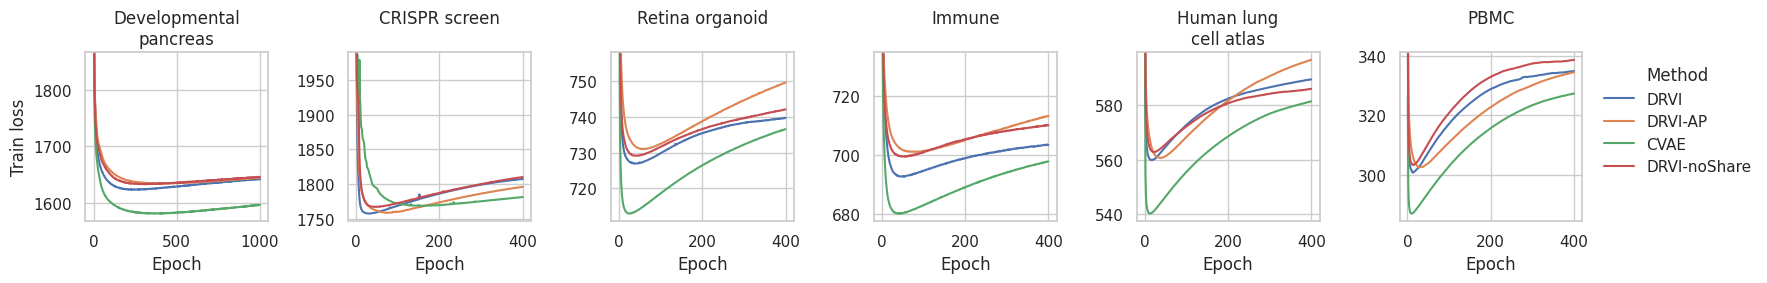

reconstruction_loss_train


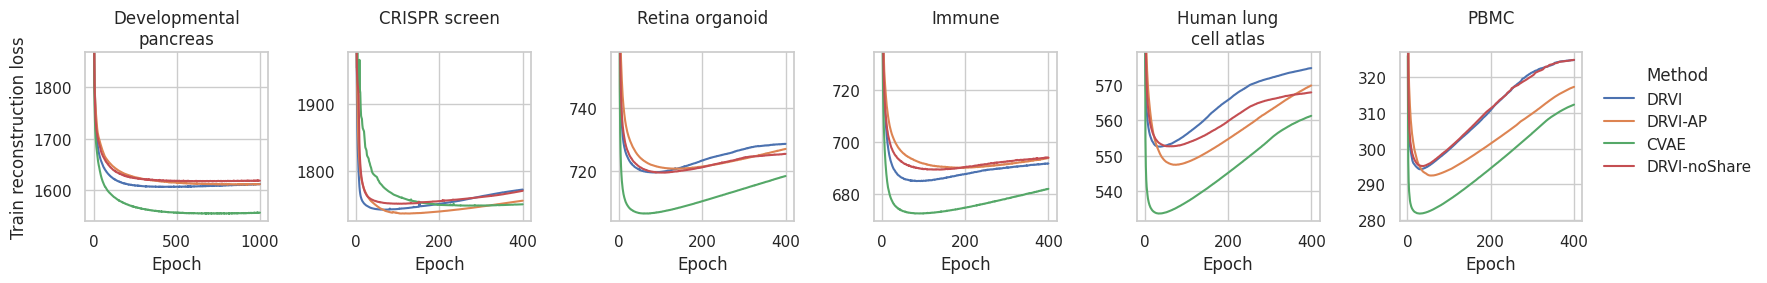

elbo_train


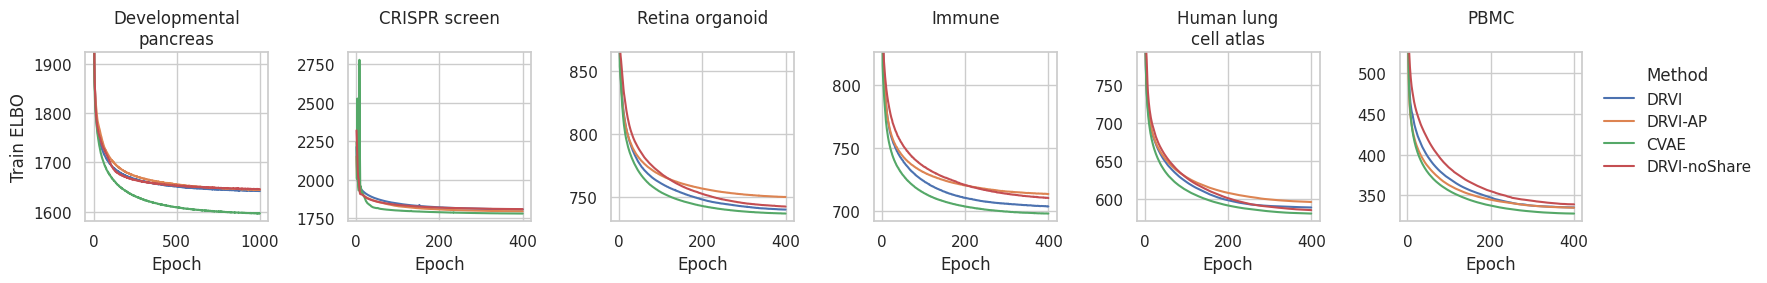

mse_train


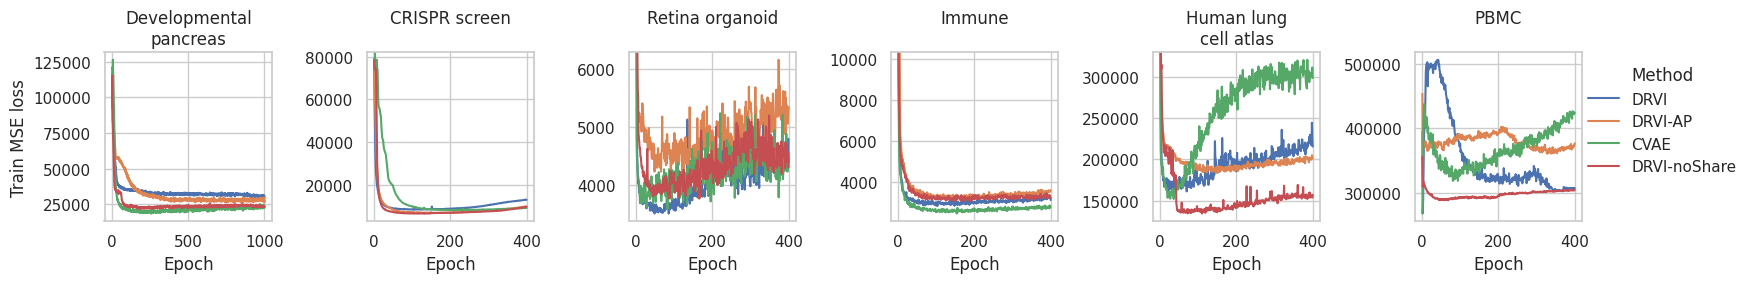

kl_local_train


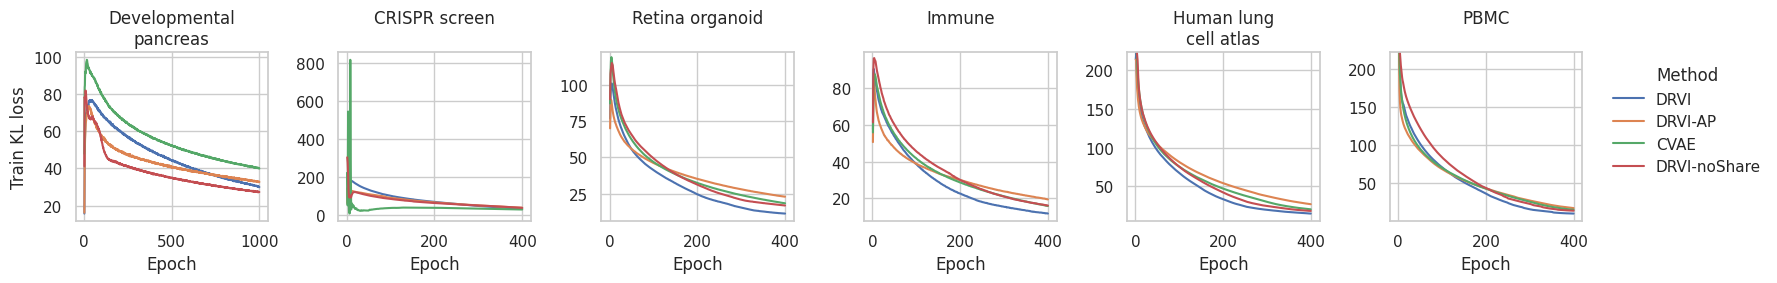

In [13]:
for metric_name in metric_titles.keys():
    print(metric_name)
    plot_metric_across_datasets(history_dict, metric_name)
    plt.tight_layout()
    plt.savefig(proj_dir / 'plots' / 'metrics_over_time' / f'{metric_name}_over_time.pdf', bbox_inches='tight', dpi=300)
    plt.show()